In [1]:
import numpy as np
import pandas as pd
import rasterio
from tqdm import tqdm
from rasterio.transform import rowcol
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

In [ ]:
maize_env = pd.read_csv('../../dataset/region prediction/maize_soil_all.csv')
wheat_env = pd.read_csv('../../dataset/region prediction/wheat_soil_all.csv')
drop_cols = ['crop_type']
maize_env = maize_env.drop(
    columns=drop_cols,
    errors='ignore'
)

wheat_env = wheat_env.drop(
    columns=drop_cols,
    errors='ignore'
)

In [3]:
print(maize_env.columns.tolist())
print(wheat_env.columns.tolist())

['CEC', 'Clay', 'SOC', 'Sand', 'Silt', 'lat', 'lon', 'pH']
['CEC', 'Clay', 'SOC', 'Sand', 'Silt', 'lat', 'lon', 'pH']


In [ ]:
MAT_FILE = '../../dataset/region prediction/China_MAT.tif'
MAP_FILE = '../../dataset/region prediction/China_MAP.tif'
DEM_FILE = '../../dataset/region prediction/China_DEM.tif'

In [ ]:
for tif in [MAT_FILE, MAP_FILE, DEM_FILE]:

    with rasterio.open(tif) as src:

        print('\n==============================')
        print(tif)
        print('CRS:', src.crs)
        print('Resolution:', src.res)
        print('Width:', src.width)
        print('Height:', src.height)
        print('Bounds:', src.bounds)
        print('NoData:', src.nodata)


../../dataset/world prediction/China_MAT.tif
CRS: EPSG:4326
Resolution: (0.008983152841195215, 0.008983152841195215)
Width: 6822
Height: 3942
Bounds: BoundingBox(left=73.49559002568779, bottom=18.15274357612067, right=134.77865870832156, top=53.56433207611221)
NoData: None

../../dataset/world prediction/China_MAP.tif
CRS: EPSG:4326
Resolution: (0.008983152841195215, 0.008983152841195215)
Width: 6822
Height: 3942
Bounds: BoundingBox(left=73.49559002568779, bottom=18.15274357612067, right=134.77865870832156, top=53.56433207611221)
NoData: None

../../dataset/world prediction/China_DEM.tif
CRS: EPSG:4326
Resolution: (0.008983152841195214, 0.008983152841195214)
Width: 6822
Height: 3942
Bounds: BoundingBox(left=73.49545113679883, bottom=18.156612954601584, right=134.77851981943257, top=53.568201454593115)
NoData: None


In [6]:
def extract_raster(df, raster_path, new_col, scale_factor=1):

    print(f'Extracting {new_col} ...')

    with rasterio.open(raster_path) as src:

        band = src.read(1)

        lon = df['lon'].values
        lat = df['lat'].values

        rows, cols = rowcol(
            src.transform,
            lon,
            lat
        )

        rows = np.asarray(rows)
        cols = np.asarray(cols)

        values = np.full(
            len(df),
            np.nan,
            dtype=np.float32
        )

        valid = (
            (rows >= 0) &
            (rows < src.height) &
            (cols >= 0) &
            (cols < src.width)
        )

        values[valid] = band[
            rows[valid],
            cols[valid]
        ]

        if src.nodata is not None:
            values[
                values == src.nodata
            ] = np.nan

        df[new_col] = values / scale_factor

    print(
        f'{new_col}: {df[new_col].notna().sum():,} matched'
    )

    return df

In [7]:
# =====================================================
# MAT
# WorldClim bio01 = temperature ×10
# =====================================================

maize_env = extract_raster(
    maize_env,
    MAT_FILE,
    'MAT',
    scale_factor=10
)

wheat_env = extract_raster(
    wheat_env,
    MAT_FILE,
    'MAT',
    scale_factor=10
)

Extracting MAT ...
MAT: 1,696,965 matched
Extracting MAT ...
MAT: 708,352 matched


In [8]:
# =====================================================
# MAP
# mm/year
# =====================================================

maize_env = extract_raster(
    maize_env,
    MAP_FILE,
    'MAP'
)

wheat_env = extract_raster(
    wheat_env,
    MAP_FILE,
    'MAP'
)


Extracting MAP ...
MAP: 1,696,965 matched
Extracting MAP ...
MAP: 708,352 matched


In [9]:
# =====================================================
# DEM
# meter
# =====================================================

maize_env = extract_raster(
    maize_env,
    DEM_FILE,
    'Elevation'
)

wheat_env = extract_raster(
    wheat_env,
    DEM_FILE,
    'Elevation'
)


Extracting Elevation ...
Elevation: 1,698,155 matched
Extracting Elevation ...
Elevation: 708,430 matched


In [ ]:
# =====================================================
# statistics
# =====================================================

print('\n========== Maize ==========')

print(
    maize_env[
        ['MAT', 'MAP', 'Elevation']
    ].describe()
)

print('\n========== Wheat ==========')

print(
    wheat_env[
        ['MAT', 'MAP', 'Elevation']
    ].describe()
)

# =====================================================
# check missing values
# =====================================================

print('\n========== Missing ==========')

print(
    maize_env[
        ['MAT', 'MAP', 'Elevation']
    ].isna().sum()
)

print(
    wheat_env[
        ['MAT', 'MAP', 'Elevation']
    ].isna().sum()
)


========== Maize ==========
                MAT           MAP     Elevation
count  1.696965e+06  1.696965e+06  1.698155e+06
mean   8.814996e+00  5.994601e+02  2.794505e+02
std    5.380070e+00  2.286408e+02  3.898952e+02
min   -4.100000e+00  1.700000e+01 -1.000000e+01
25%    4.000000e+00  4.820000e+02  4.700000e+01
50%    7.900000e+00  5.590000e+02  1.550000e+02
75%    1.400000e+01  6.740000e+02  3.100000e+02
max    2.580000e+01  2.325000e+03  3.600000e+03

========== Wheat ==========
                 MAT            MAP      Elevation
count  708352.000000  708352.000000  708430.000000
mean       13.406314     666.350586     235.327087
std         3.134821     201.296844     566.045105
min        -4.400000      21.000000      -4.000000
25%        13.100000     529.000000      22.000000
50%        14.300000     657.000000      41.000000
75%        15.000000     798.000000      77.000000
max        25.700001    1919.000000    3763.000000

========== Missing ==========
MAT          1190
MA

In [11]:
maize_env.columns

Index(['CEC', 'Clay', 'SOC', 'Sand', 'Silt', 'lat', 'lon', 'pH', 'MAT', 'MAP',
       'Elevation'],
      dtype='object')

In [12]:
keep_features = ['lat', 'lon']
cluster_features = [
    'CEC',
    'Clay',
    'SOC',
    'Sand',
    'pH',
    'MAT',
    'MAP',
    'Elevation'
]

In [13]:
maize_cluster = (
    maize_env[
        cluster_features
    ]
    .dropna()
    .copy()
)

print(maize_cluster.shape)

(1696965, 8)


In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

maize_scaled = scaler.fit_transform(
    maize_cluster
)


In [15]:
np.random.seed(42)

sample_idx = np.random.choice(
    len(maize_scaled),
    size=min(
        50000,
        len(maize_scaled)
    ),
    replace=False
)

sample = maize_scaled[
    sample_idx
]

In [ ]:
results = []

for k in range(2,16):

    model = MiniBatchKMeans(
        n_clusters=k,
        batch_size=10000,
        random_state=42
    )

    labels = model.fit_predict(
        sample
    )

    results.append({
        'k':k,
        'silhouette':
            silhouette_score(
                sample,
                labels
            ),
        'calinski':
            calinski_harabasz_score(
                sample,
                labels
            ),
        'davies':
            davies_bouldin_score(
                sample,
                labels
            )
    })

result_df = pd.DataFrame(results)

print(result_df)

     k  silhouette      calinski    davies
0    2    0.308107  19854.298704  1.287744
1    3    0.328014  22341.674992  1.209817
2    4    0.232261  17215.324508  1.331668
3    5    0.251421  16969.086842  1.243374
4    6    0.268678  18227.111617  1.198618
5    7    0.278452  18059.862206  1.157159
6    8    0.278726  18134.215855  1.126677
7    9    0.246741  17119.548031  1.229493
8   10    0.249582  16241.485931  1.298380
9   11    0.233041  15704.989948  1.329312
10  12    0.237830  15208.189405  1.263749
11  13    0.247595  15025.049360  1.230065
12  14    0.232262  14560.243598  1.283033
13  15    0.227424  14168.097202  1.298891


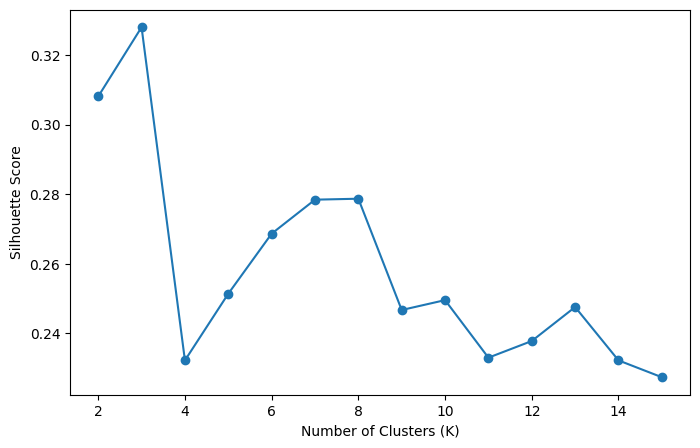

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    result_df['k'],
    result_df['silhouette'],
    marker='o'
)

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.savefig('../dataset/region prediction/maize_cluster_silhouette.jpg', dpi=600, bbox_inches='tight')
plt.show()

In [ ]:
final_model = MiniBatchKMeans(
    n_clusters=8,
    batch_size=10000,
    random_state=42
)

cluster_labels = final_model.fit_predict(
    maize_scaled
)

In [17]:
maize_env['Cluster'] = np.nan

maize_env.loc[
    maize_cluster.index,
    'Cluster'
] = cluster_labels

cluster_summary = (
    maize_env
    .groupby('Cluster')
    [
        cluster_features
    ]
    .mean()
)

print(cluster_summary)

               CEC       Clay       SOC       Sand        pH        MAT  \
Cluster                                                                   
0.0      21.328324  28.373560  1.834360  23.392501  7.414163  15.094685   
1.0      29.236951  27.313697  4.598389  29.434957  6.637220   3.045099   
2.0      22.198595  20.877896  1.584547  40.436174  7.823739   8.899339   

                MAP   Elevation  
Cluster                          
0.0      824.679626  168.958099  
1.0      580.033020  240.682129  
2.0      466.204712  380.393494  


In [ ]:
cluster_summary = (
    maize_env
    .groupby('Cluster')
    [cluster_features]
    .agg([
        'median',
        lambda x: x.quantile(0.25),
        lambda x: x.quantile(0.75)
    ])
)

print(cluster_summary.round(2))
# cluster_summary.to_excel('../../dataset/region prediction/maize_cluster_summary.xlsx', index=True)

           CEC                         Clay                          SOC  \
        median <lambda_0> <lambda_1> median <lambda_0> <lambda_1> median   
Cluster                                                                    
0.0       21.3       19.9       22.7   28.0       24.5       31.9   1.62   
1.0       29.1       27.3       31.0   27.6       24.8       29.9   4.35   
2.0       22.1       20.2       24.1   20.4       18.2       23.3   1.40   

                                Sand  ...         pH    MAT             \
        <lambda_0> <lambda_1> median  ... <lambda_1> median <lambda_0>   
Cluster                               ...                                
0.0           1.06       2.29   23.0  ...        7.9   14.8       14.1   
1.0           3.46       5.59   28.8  ...        6.9    3.0        1.8   
2.0           1.07       1.86   41.0  ...        8.0    8.1        5.8   

                      MAP                       Elevation             \
        <lambda_1> median 

In [ ]:
shandong_maize = pd.read_excel('../../dataset/region prediction/Shandong/maize.xlsx')
shandong_scaled = scaler.transform(shandong_maize[cluster_features])

In [ ]:
shandong_cluster = final_model.predict(shandong_scaled)
shandong_maize["Cluster"] = shandong_cluster
print(shandong_maize[["Cluster"]])
shandong_maize.to_excel('../../dataset/region prediction/Shandong/maize_with_cluster.xlsx', index=False)

     Cluster
0          0
1          0
2          0
3          0
4          0
..       ...
236        0
237        0
238        0
239        0
240        0

[241 rows x 1 columns]


In [ ]:
maize_env.to_csv(
    '../../dataset/region prediction/maize_clustered.csv',
    index=False
)

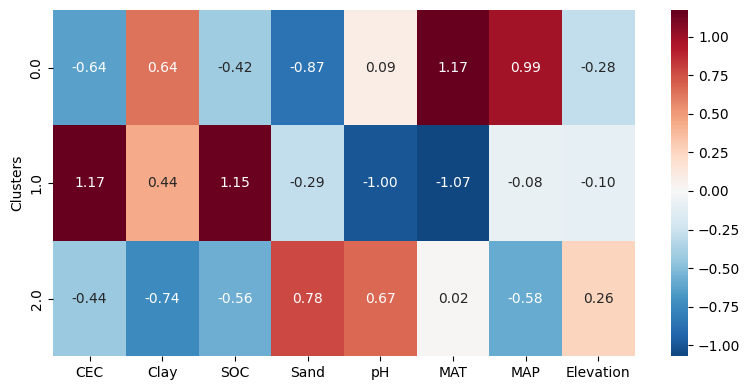

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
cluster_profile = (
    maize_env
    .groupby('Cluster')[cluster_features]
    .mean()
)

cluster_profile_z = (
    cluster_profile -
    maize_env[cluster_features].mean()
) / maize_env[cluster_features].std()
plt.figure(figsize=(8, 4))

sns.heatmap(
    cluster_profile_z,
    cmap='RdBu_r',
    center=0,
    annot=True,
    fmt='.2f'
)

#plt.xlabel('Soil properties')
plt.ylabel('Clusters')

plt.tight_layout()
#plt.savefig('../../result/maize_cluster_profile.jpg', dpi=600)
plt.show()

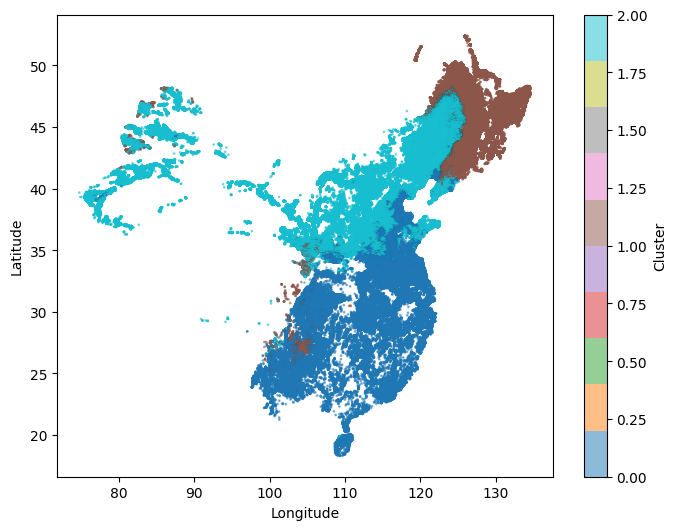

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    maize_env['lon'],
    maize_env['lat'],
    c=maize_env['Cluster'],
    s=1,
    cmap='tab10',
    alpha=0.5
)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.colorbar(label='Cluster')
plt.savefig('../../dataset/region prediction/maize_3cluster_map.jpg', dpi=600, bbox_inches='tight')
plt.show()

In [ ]:
from rasterio.transform import from_origin
# ==================================================
# 导出聚类结果为 GeoTIFF
# ==================================================

def cluster_to_tif(
        df,
        output_tif,
        resolution=0.05,
        nodata=-9999):

    print("Preparing data...")

    # save only necessary columns
    df = df[
        ['lon', 'lat', 'Cluster']
    ].copy()

    # delete rows with missing cluster values
    df = df.dropna(
        subset=['Cluster']
    )

    print(
        f"Valid points: {len(df):,}"
    )

    df['Cluster'] = (
        df['Cluster']
        .astype(np.int16)
    )

    print("Building grid...")

    df['lon_grid'] = (
        np.round(
            df['lon'] / resolution
        ) * resolution
    )

    df['lat_grid'] = (
        np.round(
            df['lat'] / resolution
        ) * resolution
    )

    # ======================================
    # same grid take majority cluster
    # ======================================

    print("Calculating majority cluster...")

    grid_df = (
        df.groupby(
            ['lat_grid', 'lon_grid']
        )['Cluster']
        .agg(
            lambda x:
            x.value_counts().idxmax()
        )
        .reset_index()
    )

    # ======================================
    # grid extent
    # ======================================

    xmin = grid_df['lon_grid'].min()
    xmax = grid_df['lon_grid'].max()

    ymin = grid_df['lat_grid'].min()
    ymax = grid_df['lat_grid'].max()

    ncols = int(
        round(
            (xmax - xmin)
            / resolution
        )
    ) + 1

    nrows = int(
        round(
            (ymax - ymin)
            / resolution
        )
    ) + 1

    print(
        f"Raster size: "
        f"{nrows} × {ncols}"
    )

    # ======================================
    # build raster array
    # ======================================

    raster = np.full(
        (nrows, ncols),
        nodata,
        dtype=np.int16
    )

    cols = (
        (
            grid_df['lon_grid']
            - xmin
        )
        / resolution
    ).round().astype(np.int32)

    rows = (
        (
            ymax
            - grid_df['lat_grid']
        )
        / resolution
    ).round().astype(np.int32)

    raster[
        rows,
        cols
    ] = grid_df[
        'Cluster'
    ].values

    # ======================================
    # space
    # ======================================

    transform = from_origin(
        xmin - resolution / 2,
        ymax + resolution / 2,
        resolution,
        resolution
    )

    # ======================================
    # write GeoTIFF
    # ======================================

    print("Writing GeoTIFF...")

    with rasterio.open(
        output_tif,
        'w',
        driver='GTiff',
        height=nrows,
        width=ncols,
        count=1,
        dtype='int16',
        crs='EPSG:4326',
        transform=transform,
        nodata=nodata,
        compress='lzw'
    ) as dst:

        dst.write(
            raster,
            1
        )

    print(
        f"Saved: {output_tif}"
    )



In [ ]:
#one tiff every cluster
import os
from rasterio.transform import from_origin
def export_each_cluster_tif(
        df,
        output_folder,
        resolution=0.05,
        nodata=-9999):

    os.makedirs(output_folder, exist_ok=True)

    print("Preparing data...")

    df = df[['lon', 'lat', 'Cluster']].copy()
    df = df.dropna(subset=['Cluster'])

    df['Cluster'] = df['Cluster'].astype(np.int16)

    # 网格化
    df['lon_grid'] = (
        np.round(df['lon'] / resolution) * resolution
    )

    df['lat_grid'] = (
        np.round(df['lat'] / resolution) * resolution
    )

    grid_df = (
        df.groupby(['lat_grid', 'lon_grid'])['Cluster']
        .agg(lambda x: x.value_counts().idxmax())
        .reset_index()
    )

    xmin = grid_df['lon_grid'].min()
    xmax = grid_df['lon_grid'].max()
    ymin = grid_df['lat_grid'].min()
    ymax = grid_df['lat_grid'].max()

    ncols = int(round((xmax - xmin) / resolution)) + 1
    nrows = int(round((ymax - ymin) / resolution)) + 1

    cols = (
        ((grid_df['lon_grid'] - xmin) / resolution)
        .round()
        .astype(int)
    )

    rows = (
        ((ymax - grid_df['lat_grid']) / resolution)
        .round()
        .astype(int)
    )

    transform = from_origin(
        xmin - resolution / 2,
        ymax + resolution / 2,
        resolution,
        resolution
    )

    clusters = sorted(grid_df['Cluster'].unique())

    print(f"Exporting {len(clusters)} clusters...")

    for c in clusters:

        raster = np.full(
            (nrows, ncols),
            nodata,
            dtype=np.int16
        )

        mask = (grid_df['Cluster'] == c)

        raster[
            rows[mask],
            cols[mask]
        ] = 1

        raster[
            (raster != 1) &
            (raster != nodata)
        ] = 0

        outfile = os.path.join(
            output_folder,
            f"Cluster_{int(c)}.tif"
        )

        with rasterio.open(
            outfile,
            'w',
            driver='GTiff',
            height=nrows,
            width=ncols,
            count=1,
            dtype='int16',
            crs='EPSG:4326',
            transform=transform,
            nodata=nodata,
            compress='lzw'
        ) as dst:

            dst.write(raster, 1)

        print(f"Saved: {outfile}")

In [26]:
maize_env['Cluster'].value_counts()

Cluster
0.0    384682
3.0    355860
5.0    274361
1.0    272628
2.0    209995
6.0     83573
4.0     82549
7.0     33317
Name: count, dtype: int64

In [ ]:
# ==================================================
# maize
# ==================================================

cluster_to_tif(
    maize_env,
    '../../dataset/region prediction/maize_cluster_005deg.tif',
    resolution=0.05
)

Preparing data...
Valid points: 1,696,965
Building grid...
Calculating majority cluster...
Raster size: 682 × 1196
Writing GeoTIFF...
Saved: ../dataset/world prediction/maize_cluster_005deg.tif


In [ ]:
export_each_cluster_tif(
    maize_env,
    "../../dataset/region prediction/ClusterTIF",
    resolution=0.05
)

Preparing data...
Exporting 8 clusters...
Saved: ../../dataset/ClusterTIF\Cluster_0.tif
Saved: ../../dataset/ClusterTIF\Cluster_1.tif
Saved: ../../dataset/ClusterTIF\Cluster_2.tif
Saved: ../../dataset/ClusterTIF\Cluster_3.tif
Saved: ../../dataset/ClusterTIF\Cluster_4.tif
Saved: ../../dataset/ClusterTIF\Cluster_5.tif
Saved: ../../dataset/ClusterTIF\Cluster_6.tif
Saved: ../../dataset/ClusterTIF\Cluster_7.tif


In [23]:
wheat_cluster = (
    wheat_env[
        cluster_features
    ]
    .dropna()
    .copy()
)

print(wheat_cluster.shape)

(708352, 8)


In [24]:
scaler = StandardScaler()

wheat_scaled = scaler.fit_transform(
    wheat_cluster
)

In [25]:
np.random.seed(42)

sample_idx = np.random.choice(
    len(wheat_scaled),
    size=min(
        30000,
        len(wheat_scaled)
    ),
    replace=False
)

wheat_sample = wheat_scaled[
    sample_idx
]

In [50]:
results = []

for k in range(2, 16):

    model = MiniBatchKMeans(
        n_clusters=k,
        batch_size=10000,
        random_state=42
    )

    labels = model.fit_predict(
        wheat_sample
    )

    results.append({
        'k': k,
        'silhouette': silhouette_score(
            wheat_sample,
            labels
        ),
        'calinski': calinski_harabasz_score(
            wheat_sample,
            labels
        ),
        'davies': davies_bouldin_score(
            wheat_sample,
            labels
        )
    })

result_df = pd.DataFrame(results)

print(result_df)

     k  silhouette      calinski    davies
0    2    0.265948   8082.003925  1.629165
1    3    0.320094  14767.275573  1.107190
2    4    0.243583  12363.781512  1.331984
3    5    0.192012  10265.262488  1.449584
4    6    0.197519   9923.992332  1.412540
5    7    0.207206   9630.641952  1.330337
6    8    0.190324   8562.837306  1.461429
7    9    0.200014   8513.857030  1.393681
8   10    0.196710   8056.288576  1.420877
9   11    0.180052   7694.553339  1.436969
10  12    0.185450   7450.634842  1.400915
11  13    0.188216   7145.946332  1.354478
12  14    0.186731   6915.946453  1.409534
13  15    0.188469   6769.957211  1.406365


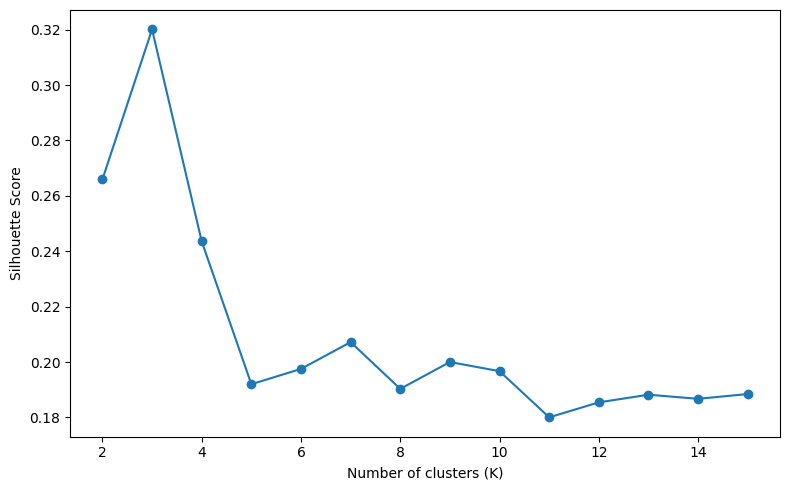

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    result_df['k'],
    result_df['silhouette'],
    marker='o'
)

plt.xlabel('Number of clusters (K)')
plt.ylabel('Silhouette Score')

plt.tight_layout()
plt.savefig('../../dataset/region prediction/wheat_cluster_silhouette.jpg', dpi=600, bbox_inches='tight')
plt.show()

In [26]:
k = 3

final_model = MiniBatchKMeans(
    n_clusters=k,
    batch_size=10000,
    random_state=42
)

cluster_labels = final_model.fit_predict(
    wheat_scaled
)

In [53]:
wheat_env['Cluster'] = np.nan

wheat_env.loc[
    wheat_cluster.index,
    'Cluster'
] = cluster_labels

In [63]:
cluster_summary = (
    wheat_env
    .groupby('Cluster')
    [
        cluster_features
    ]
    .mean()
)

print(cluster_summary.round(3))

            CEC    Clay    SOC    Sand     pH     MAT         MAP    Elevation
Cluster                                                                       
0.0      21.382  30.917  1.887  20.102  7.468  15.143  850.172974    51.757000
1.0      24.824  22.406  4.640  32.056  7.442   4.857  465.631012  1669.657959
2.0      21.193  21.775  1.088  30.006  7.941  13.629  566.494995   118.850998


In [ ]:
shandong_wheat = pd.read_excel('../../dataset/region prediction/Shandong/wheat.xlsx')
shandong_wheat_scaled = scaler.transform(shandong_wheat[cluster_features])
shandong_wheat_cluster = final_model.predict(shandong_wheat_scaled)
shandong_wheat["Cluster"] = shandong_wheat_cluster
print(shandong_wheat[["Cluster"]])
shandong_wheat.to_excel('../../dataset/region prediction/Shandong/wheat_with_cluster.xlsx', index=False)

     Cluster
0          2
1          2
2          2
3          2
4          2
..       ...
335        2
336        2
337        2
338        2
339        2

[340 rows x 1 columns]


In [ ]:
cluster_summary = (
    wheat_env
    .groupby('Cluster')
    [cluster_features]
    .agg([
        'median',
        lambda x: x.quantile(0.25),
        lambda x: x.quantile(0.75)
    ])
)

print(cluster_summary.round(2))
cluster_summary.to_excel('../../dataset/region prediction/wheat_cluster_summary.xlsx', index=True)

           CEC                         Clay                          SOC  \
        median <lambda_0> <lambda_1> median <lambda_0> <lambda_1> median   
Cluster                                                                    
0.0       21.3       20.0       22.7   30.9       27.8       34.0   1.78   
1.0       24.3       21.4       27.5   22.1       19.9       24.6   4.51   
2.0       21.2       19.9       22.5   21.6       19.4       24.1   0.98   

                                Sand  ...         pH    MAT             \
        <lambda_0> <lambda_1> median  ... <lambda_1> median <lambda_0>   
Cluster                               ...                                
0.0           1.47       2.16   19.7  ...        7.8   15.1       14.8   
1.0           3.48       5.50   31.4  ...        7.9    4.7        3.2   
2.0           0.82       1.22   28.6  ...        8.1   13.8       13.0   

                      MAP                       Elevation             \
        <lambda_1> median 

In [ ]:
wheat_env.to_csv(
    '../../dataset/region prediction/wheat_clustered.csv',
    index=False
)

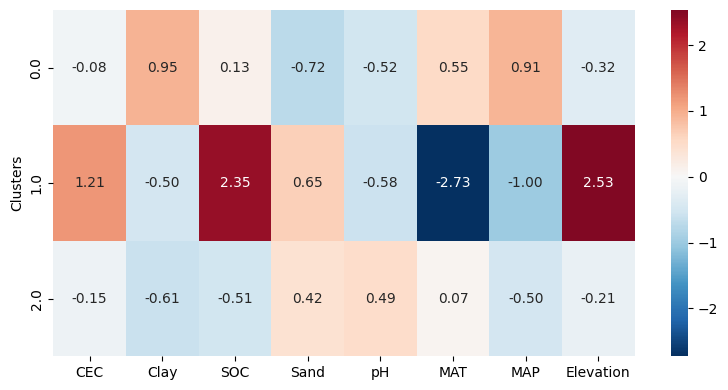

In [ ]:
cluster_profile = (
    wheat_env
    .groupby('Cluster')[cluster_features]
    .mean()
)

cluster_profile_z = (
    cluster_profile -
    wheat_env[cluster_features].mean()
) / wheat_env[cluster_features].std()
plt.figure(figsize=(8, 4))

sns.heatmap(
    cluster_profile_z,
    cmap='RdBu_r',
    center=0,
    annot=True,
    fmt='.2f'
)

#plt.xlabel('Soil properties')
plt.ylabel('Clusters')

plt.tight_layout()
plt.savefig('../../result/wheat_cluster_profile.jpg', dpi=600)
plt.show()

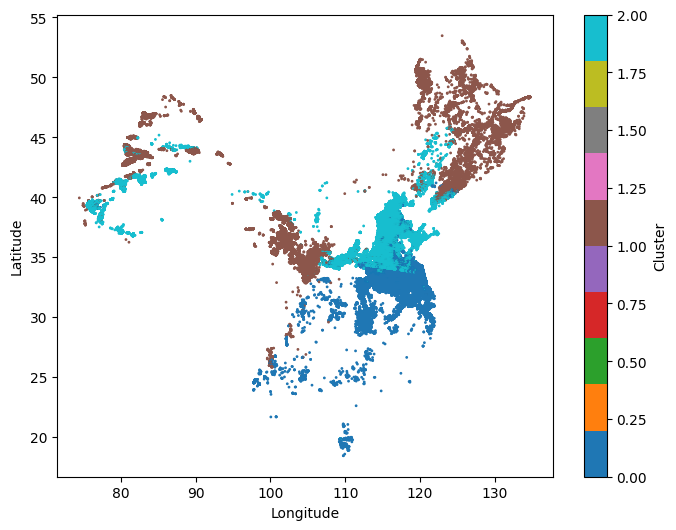

In [57]:
plt.figure(figsize=(8, 6))

plt.scatter(
    wheat_env['lon'],
    wheat_env['lat'],
    c=wheat_env['Cluster'],
    s=1,
    cmap='tab10'
)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.colorbar(label='Cluster')

plt.show()

In [ ]:
cluster_to_tif(
    wheat_env,
    '../../dataset/region prediction/wheat_cluster_005deg.tif',
    resolution=0.05
)

Preparing data...
Valid points: 708,352
Building grid...
Calculating majority cluster...
Raster size: 702 × 1206
Writing GeoTIFF...
Saved: ../dataset/world prediction/wheat_cluster_005deg.tif
